Loading dataset

In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


In [292]:
sales_data = pd.read_csv('sales_data.csv')
sales_data




,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-2025,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-2025,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,07-07-2025,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,08-07-2025,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,08-07-2025,DELAYED,Credit Card,West,0.20
...,...,...,...,...,...,...,...,...,...,...
2995,O868860,C00233,P0001,5,43.40,29-05-2025,Delivered,Bank Transfer,West,0.20
2996,O949709,C00246,P0029,4,34.04,29-05-2025,DELAYED,Bank Transfer,West,0.20
2997,O763639,C00182,P0026,1,42.34,29-05-2025,Delivered,credit card,South,0.00
2998,O753958,C00074,P0003,5,35.96,29-05-2025,Delivered,Credit Card,Central,0.00


In [293]:

customer_data = pd.read_csv('customer_info.csv')
customer_data

,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold
3,C00004,yherrera@arnold.org,14-06-25,FEMALE,Central,GOLD
4,C00005,janetwilliams@gmail.com,02-05-25,Male,West,bronze
...,...,...,...,...,...,...
495,C00496,simsjohn@wiley.net,19-02-25,femle,Central,GOLD
496,C00497,cameronwilliams@yahoo.com,30-12-24,NaN,West,GOLD
497,C00498,ibarron@yahoo.com,21-06-25,male,South,Silver
498,C00499,karen26@gmail.com,02-10-24,Female,North,gold


In [294]:
product_data = pd.read_csv('product_info.csv')
product_data

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,19-04-25,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,20-10-24,31.10,S559
5,P0006,Cleaning Product 16,Cleaning,09-10-24,36.06,S980
6,P0007,Personal Care Product 64,Personal Care,30-09-24,33.63,S379
7,P0008,Storage Product 47,Storage,29-08-24,31.96,S788
8,P0009,Outdoors Product 13,Outdoors,18-04-25,8.00,S695
9,P0010,Cleaning Product 70,Cleaning,14-08-24,17.72,S321


Data cleaning 

Standardise text formatting

In [295]:
sales_data['delivery_status']=sales_data['delivery_status'].str.strip().replace({'delivered':'Delivered','DELAYED':'Delayed','cancelled':'Cancelled','delrd':'Delivered','delyd':'Delayed'})

sales_data['payment_method']=sales_data['payment_method'].str.strip().replace({'credit card':'Credit Card','paypal':'PayPal','bank transfr':'Bank Transfer','cash':'Cash'})
sales_data['region']=sales_data['region'].str.strip().replace({'nrth':'North','south':'South','east':'East','west':'West'})
customer_data['gender']=customer_data['gender'].str.strip().replace({'MALE':'Male','FEMALE':'Female','male':'Male','female':'Female','femle':'Female'})
customer_data['loyalty_tier']=customer_data['loyalty_tier'].str.strip().replace({'BRONZE':'Bronze','bronze':'Bronze','SILVER':'Silver','silver':'Silver','sllver':'Silver','brnze':'Bronze','GOLD':'Gold','gold':'Gold','gld':'Gold','PLATINUM':'Platinum','platinum':'Platinum'})
customer_data['loyalty_tier'].value_counts()


loyalty_tier
Gold      265
Silver    119
Bronze    114
Name: count, dtype: int64

 Convert date columns 

In [296]:
sales_data['order_date']=pd.to_datetime(sales_data['order_date'], errors='coerce')
sales_data['quantity']=pd.to_numeric(sales_data['quantity'], errors='coerce').astype('Int64')
customer_data['signup_date']=pd.to_datetime(customer_data['signup_date'], errors='coerce')
product_data['launch_date']=pd.to_datetime(product_data['launch_date'], errors='coerce')
product_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   product_id     30 non-null     str           
 1   product_name   30 non-null     str           
 2   category       30 non-null     str           
 3   launch_date    30 non-null     datetime64[us]
 4   base_price     30 non-null     float64       
 5   supplier_code  30 non-null     str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 1.5 KB


/var/folders/ny/mvjvnvb130bdw8728wx5q__w0000gn/T/ipykernel_78356/3598727454.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_data['signup_date']=pd.to_datetime(customer_data['signup_date'], errors='coerce')
/var/folders/ny/mvjvnvb130bdw8728wx5q__w0000gn/T/ipykernel_78356/3598727454.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  product_data['launch_date']=pd.to_datetime(product_data['launch_date'], errors='coerce')


 Handle missing values:

Sales data

In [297]:
sales_data.isnull().sum()
sales_data['delivery_status'] = sales_data['delivery_status'].fillna('Unknown')
sales_data['payment_method'] = sales_data['payment_method'].fillna('Unknown')
sales_data['region'] = sales_data['region'].fillna('Unknown')
sales_data['quantity'] = sales_data['quantity'].fillna(sales_data['quantity'].median())
sales_data['unit_price'] = sales_data['unit_price'].fillna(sales_data['unit_price'].median())
sales_data['discount_applied'] = sales_data['discount_applied'].fillna(0)



Customer data

In [298]:
customer_data.isnull().sum()
cols_to_fix = ['gender', 'region', 'loyalty_tier']
customer_data[cols_to_fix] = customer_data[cols_to_fix].fillna('Unknown')

Product data

In [299]:
product_data.isnull().sum()

product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64

Dropping NaN Values

 Sales Data


A sales record without order_id or product_id is statistical noise . keeping incomplete data slows down filtering operations and makes graphs less precise.

The order_date column was retained despite a high proportion of missing values (60.6%). Imputation was not performed due to the risk of introducing inaccurate time-based information. Instead, rows with valid dates were used selectively for analyses requiring temporal insights.

In [300]:

sales_data.dropna(subset=['order_id', 'customer_id', 'product_id'], inplace=True)
sales_data.isnull().sum()


order_id               0
customer_id            0
product_id             0
quantity               0
unit_price             0
order_date          1815
delivery_status        0
payment_method         0
region                 0
discount_applied       0
dtype: int64

Customer

The dataset contains minimal missing values across key variables, with less than 1% missing in customer_id, email, and signup_date. Rows with missing customer_id were removed due to their importance as unique identifiers, while other missing values were handled using appropriate imputation or left unchanged where they did not affect the analysis

In [301]:
customer_data['signup_date'] = customer_data['signup_date'].fillna(customer_data['signup_date'].median())
customer_data['email'] = customer_data['email'].fillna('Unknown')
customer_data = customer_data.dropna(subset=['customer_id'])



 Remove duplicates:

Sales Dataset

In [302]:
sales_data.drop_duplicates(subset=['order_id'],keep='first', inplace=True)
sales_data

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,2025-06-07,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,2025-06-07,Delayed,Credit Card,North,0.00
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20
...,...,...,...,...,...,...,...,...,...,...
2995,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20
2996,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20
2997,O763639,C00182,P0026,1,42.34,NaT,Delivered,Credit Card,South,0.00
2998,O753958,C00074,P0003,5,35.96,NaT,Delivered,Credit Card,Central,0.00


Product

In [303]:
product_data.duplicated().sum()


np.int64(0)

Customer

In [304]:
customer_data.duplicated().sum()

np.int64(0)

 Validate numeric columns:

In [305]:
sales_data=sales_data[(sales_data['quantity'] >0) &(sales_data['unit_price'] >0)& (sales_data['discount_applied']>0)]
sales_data

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20
5,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10
6,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05
...,...,...,...,...,...,...,...,...,...,...
2993,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15
2994,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20
2995,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20
2996,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20


In [306]:
product_data[product_data['base_price'] >= 0 ]

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,2025-11-03,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,2024-08-18,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,2025-04-19,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559
5,P0006,Cleaning Product 16,Cleaning,2024-09-10,36.06,S980
6,P0007,Personal Care Product 64,Personal Care,2024-09-30,33.63,S379
7,P0008,Storage Product 47,Storage,2024-08-29,31.96,S788
8,P0009,Outdoors Product 13,Outdoors,2025-04-18,8.00,S695
9,P0010,Cleaning Product 70,Cleaning,2024-08-14,17.72,S321


3. Merge the Data

In [307]:
merged_data = pd.merge(sales_data, product_data, on='product_id', how='left')
merged_data


,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,product_name,category,launch_date,base_price,supplier_code
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,Outdoors Product 55,Outdoors,2024-09-21,23.05,S127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,Storage Product 87,Storage,2025-02-24,26.33,S558
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,Storage Product 39,Storage,2025-11-03,15.88,S339
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,Cleaning Product 69,Cleaning,2025-03-15,23.41,S424


The dataset includes 1995  transactions made by 497 customers on a catalog of 30 products . A geographical discrepancy was detected in 80% of cases between the customer's residence and the order destination; the analysis was conducted based on the Destination Region to ensure the accuracy of the logistics and revenue data.

In [308]:
merged_df= pd.merge(merged_data, customer_data.drop(columns=['region']), on=['customer_id' ], how='left')
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,loyalty_tier
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Gold
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Female,Gold
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559,abbottdominique@yahoo.com,2024-09-23,Male,Gold
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,Outdoors Product 55,Outdoors,2024-09-21,23.05,S127,adamsnorman@moore.com,2024-08-07,Female,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,Storage Product 87,Storage,2025-02-24,26.33,S558,erica21@lucas.org,2024-11-24,Female,Gold
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559,melissaturner@hotmail.com,2024-08-31,Female,Bronze
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,Storage Product 39,Storage,2025-11-03,15.88,S339,ryanbartlett@guerra.com,2024-01-11,Other,Silver
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,Cleaning Product 69,Cleaning,2025-03-15,23.41,S424,brandywilliams@simpson-khan.info,2024-10-24,Male,Gold


4. Feature Engineering

4.1 revenue = quantity × unit_price × (1 - discount_applied)

In [309]:
merged_df['revenue'] = merged_df['quantity'] * merged_df['unit_price'] * (1 - merged_df['discount_applied'])
merged_df.head(10)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,loyalty_tier,revenue
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Gold,25.228
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Female,Gold,26.208
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold,38.096
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,Personal Care Product 1,Personal Care,2024-10-20,31.10,S559,abbottdominique@yahoo.com,2024-09-23,Male,Gold,102.303
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,Outdoors Product 55,Outdoors,2024-09-21,23.05,S127,adamsnorman@moore.com,2024-08-07,Female,Gold,146.4425
5,O170570,C00076,P0030,3,28.32,NaT,Delivered,PayPal,Central,0.15,Cleaning Product 72,Cleaning,2025-04-04,9.77,S455,jeffrey10@herring.com,2025-04-03,Female,Gold,72.216
6,O619944,C00330,P0002,1,30.96,NaT,Delayed,Credit Card,South,0.15,Cleaning Product 82,Cleaning,2024-08-18,34.23,S974,ryanhawkins@russell.com,2025-02-22,Other,Bronze,26.316
7,O865247,C00249,P0022,5,30.92,NaT,Delayed,Credit Card,East,0.10,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,theresalong@grant-diaz.com,2024-09-21,Male,Gold,139.14
8,O315552,C00110,P0007,4,28.74,NaT,Delivered,Bank Transfer,North,0.10,Personal Care Product 64,Personal Care,2024-09-30,33.63,S379,harrisonricky@yahoo.com,2025-03-23,Female,Gold,103.464
9,O305482,C00404,P0003,4,9.79,NaT,Cancelled,Bank Transfer,North,0.15,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,shawrachel@gmail.com,2024-09-30,Male,Gold,33.286


4.2 order_week = ISO week from order_date

In [310]:
merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,category,launch_date,base_price,supplier_code,email,signup_date,gender,loyalty_tier,revenue,order_week
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Gold,25.228,28
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Female,Gold,26.208,32
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold,38.096,32
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,Personal Care,2024-10-20,31.10,S559,abbottdominique@yahoo.com,2024-09-23,Male,Gold,102.303,41
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,Outdoors,2024-09-21,23.05,S127,adamsnorman@moore.com,2024-08-07,Female,Gold,146.4425,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,Storage,2025-02-24,26.33,S558,erica21@lucas.org,2024-11-24,Female,Gold,45.696,40
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,Personal Care,2024-10-20,31.10,S559,melissaturner@hotmail.com,2024-08-31,Female,Bronze,35.008,45
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,...,Storage,2025-11-03,15.88,S339,ryanbartlett@guerra.com,2024-01-11,Other,Silver,173.6,<NA>
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,...,Cleaning,2025-03-15,23.41,S424,brandywilliams@simpson-khan.info,2024-10-24,Male,Gold,108.928,<NA>


Grouping the data into quarters

In [311]:
merged_df['month_quarter']= 'Q'+ (merged_df['order_date'].dt.quarter.astype('Int64')).astype('str')
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,launch_date,base_price,supplier_code,email,signup_date,gender,loyalty_tier,revenue,order_week,month_quarter
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Gold,25.228,28,Q3
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Female,Gold,26.208,32,Q3
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold,38.096,32,Q3
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,2024-10-20,31.10,S559,abbottdominique@yahoo.com,2024-09-23,Male,Gold,102.303,41,Q4
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,2024-09-21,23.05,S127,adamsnorman@moore.com,2024-08-07,Female,Gold,146.4425,49,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,2025-02-24,26.33,S558,erica21@lucas.org,2024-11-24,Female,Gold,45.696,40,Q4
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,2024-10-20,31.10,S559,melissaturner@hotmail.com,2024-08-31,Female,Bronze,35.008,45,Q4
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,...,2025-11-03,15.88,S339,ryanbartlett@guerra.com,2024-01-11,Other,Silver,173.6,<NA>,NaN
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,...,2025-03-15,23.41,S424,brandywilliams@simpson-khan.info,2024-10-24,Male,Gold,108.928,<NA>,NaN


4.3 price_band = Categorise unit price as Low (<£15), Medium (£15–30), High (>£30)

In [312]:
merged_df['price_band']=pd.cut(merged_df['unit_price'], bins=[0, 14, 30, np.inf], labels=['Low', 'Medium', 'High'])
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,base_price,supplier_code,email,signup_date,gender,loyalty_tier,revenue,order_week,month_quarter,price_band
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Gold,25.228,28,Q3,Medium
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,7.92,S745,smoore@gmail.com,2024-07-28,Female,Gold,26.208,32,Q3,High
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold,38.096,32,Q3,High
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,31.10,S559,abbottdominique@yahoo.com,2024-09-23,Male,Gold,102.303,41,Q4,High
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,23.05,S127,adamsnorman@moore.com,2024-08-07,Female,Gold,146.4425,49,Q4,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,26.33,S558,erica21@lucas.org,2024-11-24,Female,Gold,45.696,40,Q4,Medium
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,31.10,S559,melissaturner@hotmail.com,2024-08-31,Female,Bronze,35.008,45,Q4,Medium
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,...,15.88,S339,ryanbartlett@guerra.com,2024-01-11,Other,Silver,173.6,<NA>,NaN,High
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,...,23.41,S424,brandywilliams@simpson-khan.info,2024-10-24,Male,Gold,108.928,<NA>,NaN,High


4.4 days_to_order = Days between launch_date and order_date


In [313]:
merged_df['days_to_order'] = (merged_df['order_date'] - merged_df['launch_date']).dt.days.abs()
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,supplier_code,email,signup_date,gender,loyalty_tier,revenue,order_week,month_quarter,price_band,days_to_order
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,S645,lcook@walters-smith.com,2024-09-25,Male,Gold,25.228,28,Q3,Medium,104.0
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,S745,smoore@gmail.com,2024-07-28,Female,Gold,26.208,32,Q3,High,388.0
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold,38.096,32,Q3,High,168.0
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,S559,abbottdominique@yahoo.com,2024-09-23,Male,Gold,102.303,41,Q4,High,352.0
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,S127,adamsnorman@moore.com,2024-08-07,Female,Gold,146.4425,49,Q4,High,442.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,S558,erica21@lucas.org,2024-11-24,Female,Gold,45.696,40,Q4,Medium,223.0
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,S559,melissaturner@hotmail.com,2024-08-31,Female,Bronze,35.008,45,Q4,Medium,381.0
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,...,S339,ryanbartlett@guerra.com,2024-01-11,Other,Silver,173.6,<NA>,NaN,High,NaN
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,...,S424,brandywilliams@simpson-khan.info,2024-10-24,Male,Gold,108.928,<NA>,NaN,High,NaN


4.5 email_domain = Extract domain from email (e.g., gmail.com)


In [314]:
merged_df['email_domain'] = merged_df['email'].str.split('@').str[1]
merged_df.head(10)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,email,signup_date,gender,loyalty_tier,revenue,order_week,month_quarter,price_band,days_to_order,email_domain
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,lcook@walters-smith.com,2024-09-25,Male,Gold,25.228,28,Q3,Medium,104.0,walters-smith.com
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,smoore@gmail.com,2024-07-28,Female,Gold,26.208,32,Q3,High,388.0,gmail.com
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,mcclainkatherine@hotmail.com,2024-09-18,Male,Gold,38.096,32,Q3,High,168.0,hotmail.com
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,abbottdominique@yahoo.com,2024-09-23,Male,Gold,102.303,41,Q4,High,352.0,yahoo.com
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,adamsnorman@moore.com,2024-08-07,Female,Gold,146.4425,49,Q4,High,442.0,moore.com
5,O170570,C00076,P0030,3,28.32,NaT,Delivered,PayPal,Central,0.15,...,jeffrey10@herring.com,2025-04-03,Female,Gold,72.216,<NA>,NaN,Medium,NaN,herring.com
6,O619944,C00330,P0002,1,30.96,NaT,Delayed,Credit Card,South,0.15,...,ryanhawkins@russell.com,2025-02-22,Other,Bronze,26.316,<NA>,NaN,High,NaN,russell.com
7,O865247,C00249,P0022,5,30.92,NaT,Delayed,Credit Card,East,0.10,...,theresalong@grant-diaz.com,2024-09-21,Male,Gold,139.14,<NA>,NaN,High,NaN,grant-diaz.com
8,O315552,C00110,P0007,4,28.74,NaT,Delivered,Bank Transfer,North,0.10,...,harrisonricky@yahoo.com,2025-03-23,Female,Gold,103.464,<NA>,NaN,Medium,NaN,yahoo.com
9,O305482,C00404,P0003,4,9.79,NaT,Cancelled,Bank Transfer,North,0.15,...,shawrachel@gmail.com,2024-09-30,Male,Gold,33.286,<NA>,NaN,Low,NaN,gmail.com


4.6 is_late = True if delivery_status is "Delayed"

In [315]:
merged_df['is_late_delivery'] = merged_df['delivery_status'].apply(lambda x: True if x == 'Delayed' else False)
merged_df.head(10)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,signup_date,gender,loyalty_tier,revenue,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,2024-09-25,Male,Gold,25.228,28,Q3,Medium,104.0,walters-smith.com,False
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,2024-07-28,Female,Gold,26.208,32,Q3,High,388.0,gmail.com,False
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,2024-09-18,Male,Gold,38.096,32,Q3,High,168.0,hotmail.com,True
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,2024-09-23,Male,Gold,102.303,41,Q4,High,352.0,yahoo.com,True
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,2024-08-07,Female,Gold,146.4425,49,Q4,High,442.0,moore.com,False
5,O170570,C00076,P0030,3,28.32,NaT,Delivered,PayPal,Central,0.15,...,2025-04-03,Female,Gold,72.216,<NA>,NaN,Medium,NaN,herring.com,False
6,O619944,C00330,P0002,1,30.96,NaT,Delayed,Credit Card,South,0.15,...,2025-02-22,Other,Bronze,26.316,<NA>,NaN,High,NaN,russell.com,True
7,O865247,C00249,P0022,5,30.92,NaT,Delayed,Credit Card,East,0.10,...,2024-09-21,Male,Gold,139.14,<NA>,NaN,High,NaN,grant-diaz.com,True
8,O315552,C00110,P0007,4,28.74,NaT,Delivered,Bank Transfer,North,0.10,...,2025-03-23,Female,Gold,103.464,<NA>,NaN,Medium,NaN,yahoo.com,False
9,O305482,C00404,P0003,4,9.79,NaT,Cancelled,Bank Transfer,North,0.15,...,2024-09-30,Male,Gold,33.286,<NA>,NaN,Low,NaN,gmail.com,False


5. Create Summary Tables

Weekly revenue trends by region

In [ ]:

merged_df["weekly"] = merged_df['order_date'].dt.to_period('W')
weekly_trend = merged_df.pivot_table(
    index='weekly', 
    columns='region', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)
weekly_trend['row_total']=weekly_trend.sum(axis=1)


weekly_trend.astype('Int64')

region,Central,East,North,South,West,row_total
weekly,,,,,,
2024-12-30/2025-01-05,0,103,20,55,77,257
2025-01-06/2025-01-12,1824,343,584,1029,1249,5031
2025-02-03/2025-02-09,1149,1694,1013,960,948,5765
2025-03-03/2025-03-09,1068,938,604,1389,859,4861
2025-03-31/2025-04-06,726,223,725,594,668,2938
2025-04-07/2025-04-13,137,628,556,560,193,2075
2025-04-28/2025-05-04,0,47,17,0,0,65
2025-05-05/2025-05-11,484,1188,1462,1194,672,5001
2025-06-02/2025-06-08,708,1234,1013,1080,1265,5302


Weekly totla by region

In [362]:
column_total=weekly_trend.sum(axis=0)
column_total.astype('Int64').sort_index(ascending=False)

region
row_total    61135
West         12678
South        12465
North        10508
East         12269
Central      13214
dtype: Int64

Product category performance (revenue, quantity, discount)

In [317]:

measures=['revenue','quantity','discount_applied']

Product_category_performance=merged_df.groupby(['category'])[measures].sum().round(0).sort_values(by='revenue', ascending=False)
Product_category_performance

,revenue,quantity,discount_applied
category,,,
Cleaning,61709.0,2453,103.0
Storage,29413.0,1151,47.0
Outdoors,26650.0,1032,42.0
Kitchen,20269.0,757,30.0
Personal Care,15817.0,598,26.0


Customer behaviour by loyalty_tier and signup_month

Extract the month name from the sign up date

In [318]:
merged_df['month_name'] = merged_df['signup_date'].dt.month_name()
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,loyalty_tier,revenue,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery,weekly,month_name
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,Gold,25.228,28,Q3,Medium,104.0,walters-smith.com,False,2025-07-07/2025-07-13,September
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,Gold,26.208,32,Q3,High,388.0,gmail.com,False,2025-08-04/2025-08-10,July
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,Gold,38.096,32,Q3,High,168.0,hotmail.com,True,2025-08-04/2025-08-10,September
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,Gold,102.303,41,Q4,High,352.0,yahoo.com,True,2025-10-06/2025-10-12,September
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,Gold,146.4425,49,Q4,High,442.0,moore.com,False,2025-12-01/2025-12-07,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,Gold,45.696,40,Q4,Medium,223.0,lucas.org,False,2025-09-29/2025-10-05,November
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,Bronze,35.008,45,Q4,Medium,381.0,hotmail.com,True,2025-11-03/2025-11-09,August
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,...,Silver,173.6,<NA>,NaN,High,NaN,guerra.com,False,NaT,January
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,...,Gold,108.928,<NA>,NaN,High,NaN,simpson-khan.info,True,NaT,October


Customer behaviour by loyalty_tier and signup_month

In [319]:

customer_behaviour=merged_df.groupby(['month_name','loyalty_tier'])['revenue'].agg(['sum','mean']).unstack().fillna(0).astype('Int64')
customer_behaviour



sum                         mean                    
loyalty_tier Bronze   Gold Silver Unknown Bronze Gold Silver Unknown
month_name                                                          
April          1078   7863   3606       0     59   76     72       0
August         2444   6047   2079       0     76   67     79       0
December       2696   8425   1026       0     61   75     64       0
February       3165   6420   2596     262     68   89     78      87
January        1409   7766   2809       0     61   80     68       0
July           1826   7311   1866       0     62   88     64       0
June           3525   4490   3606       0     75   74     80       0
March          3070   4655   4610       0     87   68     75       0
May            2332   5719   3443     356     83   73     88     118
November       2783   7961   4744       0     86   79     93       0
October        3357   8929   3794       0     83   79     79       0
September      2192  11051   1817       0     78   83     67       0

Delivery performance by region and price_band

In [320]:
cat=['price_band', 'region']
delivery_performance_pb_region=merged_df.groupby(['delivery_status'])[cat].value_counts().unstack(fill_value=0)
delivery_performance_pb_region

region                      Central  East  North  South  West
delivery_status price_band                                   
Cancelled       Low              12    10     18     14     5
                Medium           37    23     21     23    49
                High             32    31     36     35    40
Delayed         Low              22    21     32     19    18
                Medium           70    69     58     49    59
                High             71    70     74     96    69
Delivered       Low              25    19     26     25    21
                Medium           68    75     49     55    62
                High             68    76     92     80    69
Unknown         Low               0     0      1      0     0
                Medium            0     0      0      0     0
                High              0     1      0      0     0

In [321]:
merged_df.pivot_table( index=['region','price_band' ], columns='delivery_status', aggfunc='size').unstack().fillna(0)

delivery_status Cancelled              Delayed              Delivered         \
price_band            Low Medium  High     Low Medium  High       Low Medium   
region                                                                         
Central              12.0   37.0  32.0    22.0   70.0  71.0      25.0   68.0   
East                 10.0   23.0  31.0    21.0   69.0  70.0      19.0   75.0   
North                18.0   21.0  36.0    32.0   58.0  74.0      26.0   49.0   
South                14.0   23.0  35.0    19.0   49.0  96.0      25.0   55.0   
West                  5.0   49.0  40.0    18.0   59.0  69.0      21.0   62.0   

delivery_status       Unknown              
price_band       High     Low Medium High  
region                                     
Central          68.0     0.0    0.0  0.0  
East             76.0     0.0    0.0  1.0  
North            92.0     1.0    0.0  0.0  
South            80.0     0.0    0.0  0.0  
West             69.0     0.0    0.0  0.0

6. Are certain regions struggling with delivery delays?

In [322]:

delivery_analysis = merged_df.groupby(['region', 'price_band'])['is_late_delivery'].agg(['mean', 'count'])  


delivery_analysis['delay_rate_%'] = (delivery_analysis['mean'] * 100).round(2)
delivery_analysis.rename(columns={'count': 'total_orders'}, inplace=True)
delivery_analysis.drop(columns=['mean'], inplace=True)


delivery_analysis.unstack(fill_value=0)


total_orders             delay_rate_%              
price_band          Low Medium High          Low Medium   High
region                                                        
Central              59    175  171        37.29  40.00  41.52
East                 50    167  178        42.00  41.32  39.33
North                77    128  202        41.56  45.31  36.63
South                58    127  211        32.76  38.58  45.50
West                 44    170  178        40.91  34.71  38.76

Preferred payment methods by loyalty_tier

In [323]:
preferred_payment_methods = merged_df.groupby('loyalty_tier')['payment_method'].value_counts().unstack(fill_value=0)
preferred_payment_methods

payment_method,Bank Transfer,Credit Card,PayPal,Unknown
loyalty_tier,,,,
Bronze,122,181,99,0
Gold,257,562,285,2
Silver,135,224,106,1
Unknown,0,5,1,0


6. Visual Exploration

In [324]:
merged_df

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,loyalty_tier,revenue,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery,weekly,month_name
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,Gold,25.228,28,Q3,Medium,104.0,walters-smith.com,False,2025-07-07/2025-07-13,September
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,Gold,26.208,32,Q3,High,388.0,gmail.com,False,2025-08-04/2025-08-10,July
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,Gold,38.096,32,Q3,High,168.0,hotmail.com,True,2025-08-04/2025-08-10,September
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,Gold,102.303,41,Q4,High,352.0,yahoo.com,True,2025-10-06/2025-10-12,September
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,Gold,146.4425,49,Q4,High,442.0,moore.com,False,2025-12-01/2025-12-07,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,Gold,45.696,40,Q4,Medium,223.0,lucas.org,False,2025-09-29/2025-10-05,November
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,Bronze,35.008,45,Q4,Medium,381.0,hotmail.com,True,2025-11-03/2025-11-09,August
1992,O868860,C00233,P0001,5,43.40,NaT,Delivered,Bank Transfer,West,0.20,...,Silver,173.6,<NA>,NaN,High,NaN,guerra.com,False,NaT,January
1993,O949709,C00246,P0029,4,34.04,NaT,Delayed,Bank Transfer,West,0.20,...,Gold,108.928,<NA>,NaN,High,NaN,simpson-khan.info,True,NaT,October


1. Line plot - weekly revenue trends by region

Create Weekly Groups

Due to a high proportion of missing values (approximately 60.6%) in the order_date column, rows without valid dates were excluded only for time-based analysis. While this reduced the dataset size, it ensured the accuracy and reliability of temporal insights. All other analyses were conducted using the full dataset.

In [325]:
merged_df_time=merged_df.copy()
merged_df_time.dropna(subset=['order_date'], inplace=True)
merged_df_time

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,loyalty_tier,revenue,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery,weekly,month_name
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,Gold,25.228,28,Q3,Medium,104.0,walters-smith.com,False,2025-07-07/2025-07-13,September
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,Gold,26.208,32,Q3,High,388.0,gmail.com,False,2025-08-04/2025-08-10,July
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,Gold,38.096,32,Q3,High,168.0,hotmail.com,True,2025-08-04/2025-08-10,September
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,Gold,102.303,41,Q4,High,352.0,yahoo.com,True,2025-10-06/2025-10-12,September
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,Gold,146.4425,49,Q4,High,442.0,moore.com,False,2025-12-01/2025-12-07,August
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,O406723,C00043,P0011,5,36.05,2025-01-06,Delivered,Bank Transfer,North,0.10,...,Silver,162.225,2,Q1,High,78.0,jordan.com,False,2025-01-06/2025-01-12,November
1987,O422603,C00415,P0014,1,10.74,2025-11-05,Cancelled,PayPal,Central,0.15,...,Gold,9.129,45,Q4,Low,276.0,martinez-howard.com,False,2025-11-03/2025-11-09,December
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,Gold,45.696,40,Q4,Medium,223.0,lucas.org,False,2025-09-29/2025-10-05,November
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,Bronze,35.008,45,Q4,Medium,381.0,hotmail.com,True,2025-11-03/2025-11-09,August


create the week column

In [326]:
merged_df_time['week']=merged_df_time['order_date'].dt.to_period('W').dt.start_time
merged_df_time

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,revenue,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery,weekly,month_name,week
0,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,25.228,28,Q3,Medium,104.0,walters-smith.com,False,2025-07-07/2025-07-13,September,2025-07-07
1,O501803,C00031,P0003,1,32.76,2025-08-07,Cancelled,Credit Card,Central,0.20,...,26.208,32,Q3,High,388.0,gmail.com,False,2025-08-04/2025-08-10,July,2025-08-04
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.20,...,38.096,32,Q3,High,168.0,hotmail.com,True,2025-08-04/2025-08-10,September,2025-08-04
3,O190175,C00388,P0005,3,37.89,2025-10-07,Delayed,Bank Transfer,North,0.10,...,102.303,41,Q4,High,352.0,yahoo.com,True,2025-10-06/2025-10-12,September,2025-10-06
4,O272646,C00328,P0027,5,30.83,2025-12-07,Delivered,PayPal,Central,0.05,...,146.4425,49,Q4,High,442.0,moore.com,False,2025-12-01/2025-12-07,August,2025-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,O406723,C00043,P0011,5,36.05,2025-01-06,Delivered,Bank Transfer,North,0.10,...,162.225,2,Q1,High,78.0,jordan.com,False,2025-01-06/2025-01-12,November,2025-01-06
1987,O422603,C00415,P0014,1,10.74,2025-11-05,Cancelled,PayPal,Central,0.15,...,9.129,45,Q4,Low,276.0,martinez-howard.com,False,2025-11-03/2025-11-09,December,2025-11-03
1990,O517776,C00138,P0024,3,17.92,2025-10-05,Cancelled,Credit Card,North,0.15,...,45.696,40,Q4,Medium,223.0,lucas.org,False,2025-09-29/2025-10-05,November,2025-09-29
1991,O650396,C00298,P0005,2,21.88,2025-11-05,Delayed,Bank Transfer,Central,0.20,...,35.008,45,Q4,Medium,381.0,hotmail.com,True,2025-11-03/2025-11-09,August,2025-11-03


Key Findings & Trends


Chart 1 — Weekly revenue trends by region

In [327]:
weekly_revenue=merged_df_time.pivot_table(index='week', columns='region', values='revenue', aggfunc='sum').fillna(0)

weekly_revenue['wk_total'] = weekly_revenue.sum(axis=1).astype('Int64')

weekly_revenue

region,Central,East,North,South,West,wk_total
week,,,,,,
2024-12-30,0.0,103.071,20.7825,55.879,77.77,257
2025-01-06,1824.642,343.707,584.3755,1029.306,1249.351,5031
2025-02-03,1149.0025,1694.624,1013.163,960.5505,948.628,5765
2025-03-03,1068.838,938.697,604.852,1389.566,859.7515,4861
2025-03-31,726.9665,223.134,725.345,594.875,668.217,2938
2025-04-07,137.1035,628.378,556.764,560.4465,193.106,2075
2025-04-28,0.0,47.904,17.425,0.0,0.0,65
2025-05-05,484.232,1188.235,1462.6855,1194.577,672.195,5001
2025-06-02,708.3025,1234.4485,1013.735,1080.901,1265.243,5302


Plot the Line Chart

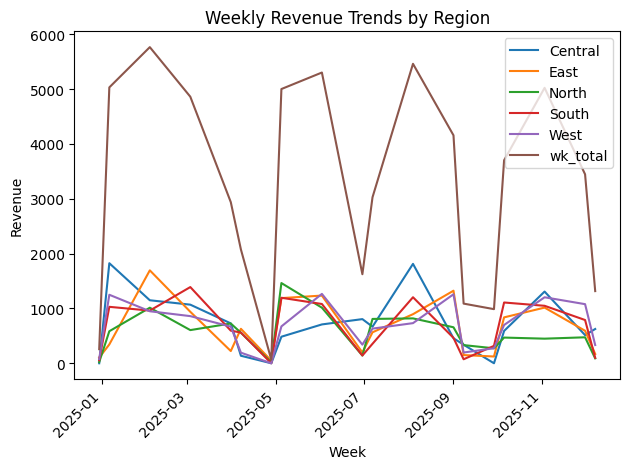

In [328]:

weekly_revenue.plot()
plt.title('Weekly Revenue Trends by Region')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar chart - top 5 categories by revenue

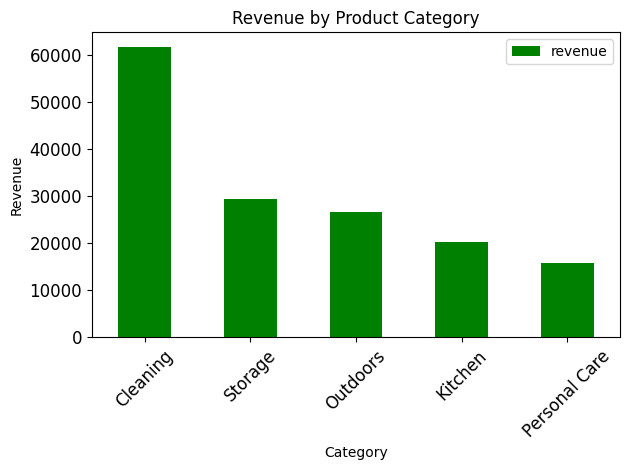

In [329]:

top_categories = merged_df.groupby('category')['revenue'].sum().nlargest(5)
top_categories.plot(kind='bar', fontsize=12, color='green')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show() 
 

Boxplot - quantity vs discount across categories

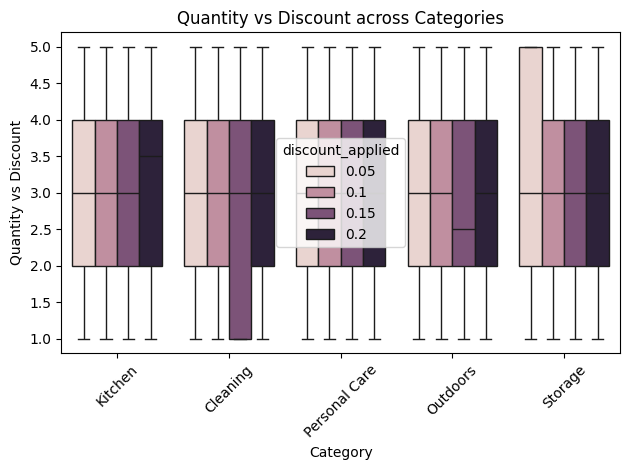

In [330]:
sns.boxplot(x='category', y='quantity', hue='discount_applied', data=merged_df)
plt.title('Quantity vs Discount across Categories')
plt.xlabel('Category')
plt.ylabel('Quantity vs Discount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Heatmap - correlation between revenue, discount, and quantity

Compute Correlation

In [331]:
corr=merged_df[['revenue','discount_applied','quantity']].corr()
corr

,revenue,discount_applied,quantity
revenue,1.000000,-0.116714,0.722153
discount_applied,-0.116714,1.000000,-0.024516
quantity,0.722153,-0.024516,1.000000


Compute Correlation

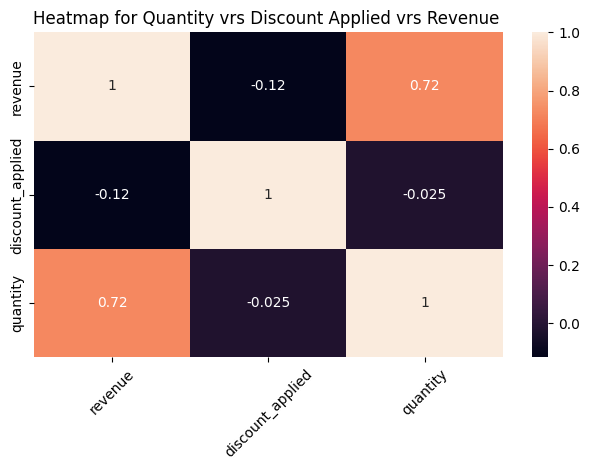

In [366]:
sns.heatmap(corr,annot=True)
plt.title('Heatmap for Quantity vrs Discount Applied vrs Revenue ')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

5. Countplot - orders by loyalty tier (with hue = region)

Text(0, 0.5, 'Loyalty Tier ')

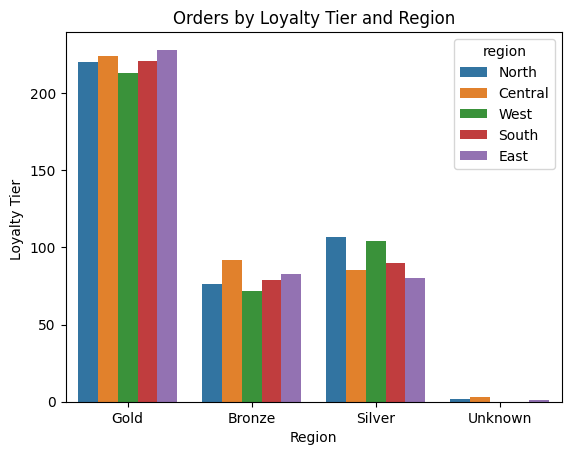

In [367]:
sns.countplot(x='loyalty_tier', hue='region', data=merged_df)
plt.title('Orders by Loyalty Tier and Region')
plt.xlabel('Region')
plt.ylabel('Loyalty Tier ')

6. Stacked bar or pie - delivery status by price band

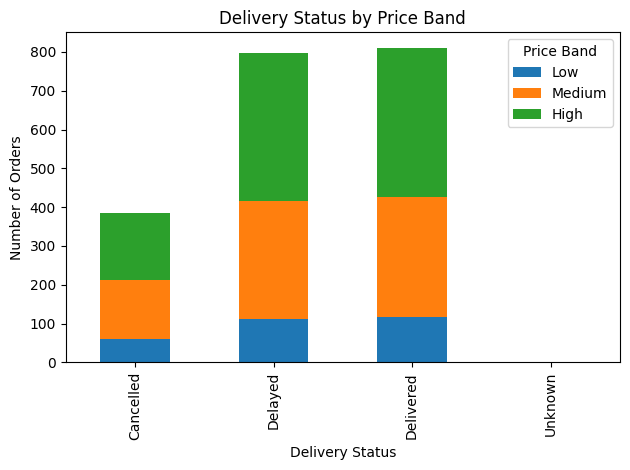

In [368]:
delivery_analysis=merged_df.groupby(['price_band', 'delivery_status']).size().unstack(0)
delivery_analysis.plot(kind='bar', stacked=True)

plt.title('Delivery Status by Price Band')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.legend(title='Price Band')
plt.tight_layout()
plt.show()  

7. Business Questions to Answer 

1. Which product categories drive the most revenue, and in which regions?

In [335]:
most_rev=merged_df.groupby(['region','category'])[ 'revenue'].sum().unstack().fillna(0).astype('Int64')
most_rev['total_revenue']=most_rev.sum(axis=1)
most_rev.sort_values(by='total_revenue', ascending=False)

category,Cleaning,Kitchen,Outdoors,Personal Care,Storage,total_revenue
region,,,,,,
South,13063,4242,6380,2812,5935,32432
West,12006,4114,5377,2894,6487,30878
East,13641,4400,4029,3231,5577,30878
Central,11092,3370,5669,3542,6547,30220
North,11904,4140,5193,3335,4865,29437


4. Do discounts lead to more items sold?

In [336]:
correlation = merged_df['discount_applied'].corr(merged_df['quantity'])
correlation

np.float64(-0.02451610284772487)

In [337]:

discount_impact =merged_df.groupby(['discount_applied']).agg(
    total_quantity=('quantity','sum'),
    avg_quantity_sold=('quantity','mean'),
    number_of_orders=('order_id','count')
)
discount_impact 

,total_quantity,avg_quantity_sold,number_of_orders
discount_applied,,,
0.05,1546,3.085828,501
0.10,1509,2.982213,506
0.15,1499,2.950787,508
0.20,1437,2.99375,480


5. Which loyalty tier generates the most value?

In [338]:
loyalty_revenue=merged_df.groupby(['loyalty_tier']).agg(
    total_revenue=('revenue','sum'),
    avg_revenue=('revenue','mean'),
    quantity_order=('order_id','count')

).sort_values(by='total_revenue', ascending=False)
loyalty_revenue.astype('Int64')


,total_revenue,avg_revenue,quantity_order
loyalty_tier,,,
Gold,86643,78,1106
Silver,36000,77,466
Bronze,29884,74,402
Unknown,619,103,6


In [339]:
pd.pivot_table(merged_df,index='loyalty_tier', values='revenue', aggfunc='sum').sort_values(by='revenue', ascending=False).astype('Int64')

,revenue
loyalty_tier,
Gold,86643
Silver,36000
Bronze,29884
Unknown,619


6. Are certain regions struggling with delivery delays?

In [340]:
struggling_regions = merged_df.groupby('region').agg(
    total_orders=('order_id', 'count'),
   
    delayed_orders=('delivery_status', lambda x: (x == 'Delayed').sum())
)

struggling_regions['delay_rate'] = ((struggling_regions['delayed_orders'] / struggling_regions['total_orders']) * 100).round(2)
struggling_regions.sort_values(by='delay_rate',ascending=False)


,total_orders,delayed_orders,delay_rate
region,,,
South,396,164,41.41
East,395,160,40.51
North,407,164,40.29
Central,405,163,40.25
West,392,146,37.24


7. Do customer signup patterns influence purchasing activity?

Calculate the delay between signup and purchase

In [341]:
merged_df_time['days_to_order'] = (merged_df_time['order_date'] - merged_df_time['signup_date']).dt.days.abs()
merged_df_time['days_to_order'].astype("Int64")

0       285
1       375
2       323
3       379
4       487
       ... 
1983     43
1987    312
1990    315
1991    431
1994    126
Name: days_to_order, Length: 783, dtype: Int64

Categorise customer behaviour

In [342]:
merged_df_time['purchase_speed'] = merged_df_time['days_to_order'].apply(
    lambda x: 'Early (≤14 days)' if x <= 14 else 'Late (>14 days)'
)
merged_df_time['purchase_speed']

0       Late (>14 days)
1       Late (>14 days)
2       Late (>14 days)
3       Late (>14 days)
4       Late (>14 days)
             ...       
1983    Late (>14 days)
1987    Late (>14 days)
1990    Late (>14 days)
1991    Late (>14 days)
1994    Late (>14 days)
Name: purchase_speed, Length: 783, dtype: str

Analyse purchasing activity

In [343]:
merged_df_time['purchase_speed'].value_counts()


purchase_speed
Late (>14 days)     751
Early (≤14 days)     32
Name: count, dtype: int64

In [344]:
signup_pattern =merged_df_time.groupby('purchase_speed').agg(
    average_quantity=('quantity', 'mean'),
    average_revenue=('revenue','mean'),
    purchace_count=('order_id','count')

)
signup_pattern

,average_quantity,average_revenue,purchace_count
purchase_speed,,,
Early (≤14 days),3.1875,83.788797,32
Late (>14 days),3.002663,77.835208,751


8. Optional Stretch Tasks

Use .query() to extract:
- Customers who signed up in Q2
- Placed an order within 14 days
- Received a discount > 20%

Days between signup and order

In [345]:
merged_df['days_signup_order']=(merged_df['order_date']-merged_df['signup_date']).dt.days.abs()
merged_df['days_signup_order'].astype('Int64')
merged_df.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'quantity',
 'unit_price',
 'order_date',
 'delivery_status',
 'payment_method',
 'region',
 'discount_applied',
 'product_name',
 'category',
 'launch_date',
 'base_price',
 'supplier_code',
 'email',
 'signup_date',
 'gender',
 'loyalty_tier',
 'revenue',
 'order_week',
 'month_quarter',
 'price_band',
 'days_to_order',
 'email_domain',
 'is_late_delivery',
 'weekly',
 'month_name',
 'days_signup_order']

In [346]:
customer_query=merged_df.query( 'month_quarter=="Q2" & days_signup_order <= 14 & discount_applied= =0.20 ')
customer_query

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,revenue,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery,weekly,month_name,days_signup_order
123,O484212,C00360,P0030,1,22.41,2025-05-08,Delivered,Bank Transfer,North,0.2,...,17.928,19,Q2,Medium,34.0,crane-washington.com,False,2025-05-05/2025-05-11,May,10.0
1211,O594114,C00371,P0005,3,29.84,2025-06-06,Delayed,Credit Card,North,0.2,...,71.616,23,Q2,Medium,229.0,yahoo.com,True,2025-06-02/2025-06-08,June,3.0
1845,O903573,C00119,P0027,2,16.89,2025-05-07,Delayed,Credit Card,West,0.2,...,27.024,19,Q2,Medium,228.0,morgan-french.com,True,2025-05-05/2025-05-11,May,13.0


In [350]:
customer_query.groupby('month_quarter').agg({
    'days_signup_order':'count',
    'discount_applied':'count'

}

)

,days_signup_order,discount_applied
month_quarter,,
Q2,3,3


Use MinMaxScaler to normalise revenue or price

In [347]:
scaler = MinMaxScaler()
merged_df['revenue_scaled'] = scaler.fit_transform(merged_df[['revenue']])
merged_df['revenue_scaled'].mean()


np.float64(0.3063931000094321)

Flag underperforming products (low quantity, high discount, delayed deliveries)

In [348]:
underperforming = merged_df[
    (merged_df['quantity'] < merged_df['quantity'].median()) &
    (merged_df['discount_applied'] >= 0.20) &
    (merged_df['delivery_status'] == 'Delayed')
]
underperforming

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied,...,order_week,month_quarter,price_band,days_to_order,email_domain,is_late_delivery,weekly,month_name,days_signup_order,revenue_scaled
2,O322242,C00495,P0016,1,47.62,2025-08-07,Delayed,Credit Card,West,0.2,...,32,Q3,High,168.0,hotmail.com,True,2025-08-04/2025-08-10,September,323.0,0.136359
17,O960238,C00259,P0009,2,9.58,NaT,Delayed,Credit Card,East,0.2,...,<NA>,NaN,Low,NaN,yahoo.com,True,NaT,June,NaN,0.037157
26,O532137,C00043,P0029,1,28.46,2025-03-07,Delayed,Credit Card,West,0.2,...,10,Q1,Medium,8.0,jordan.com,True,2025-03-03/2025-03-09,November,103.0,0.069574
93,O229936,C00437,P0027,2,20.82,NaT,Delayed,PayPal,North,0.2,...,<NA>,NaN,Medium,NaN,yahoo.com,True,NaT,February,NaN,0.115514
117,O905284,C00324,P0007,2,36.55,NaT,Delayed,PayPal,East,0.2,...,<NA>,NaN,High,NaN,davis.com,True,NaT,November,NaN,0.225173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1845,O903573,C00119,P0027,2,16.89,2025-05-07,Delayed,Credit Card,West,0.2,...,19,Q2,Medium,228.0,morgan-french.com,True,2025-05-05/2025-05-11,May,13.0,0.088117
1924,O221217,C00315,P0007,2,18.54,NaT,Delayed,Bank Transfer,South,0.2,...,<NA>,NaN,Medium,NaN,smith-li.biz,True,NaT,May,NaN,0.099620
1946,O797932,C00096,P0003,2,25.20,2025-09-06,Delayed,Bank Transfer,East,0.2,...,36,Q3,Medium,418.0,salas.com,True,2025-09-01/2025-09-07,April,158.0,0.146049
1950,O718106,C00383,P0022,1,13.50,2025-08-06,Delayed,PayPal,North,0.2,...,32,Q3,Low,483.0,garcia.com,True,2025-08-04/2025-08-10,August,343.0,0.017428


In [349]:
underperforming_table = underperforming[
    ['product_name', 'quantity', 'discount_applied', 'delivery_status', 'region']
]
underperforming_table.head(5)

,product_name,quantity,discount_applied,delivery_status,region
2,Cleaning Product 53,1,0.2,Delayed,West
17,Outdoors Product 13,2,0.2,Delayed,East
26,Cleaning Product 69,1,0.2,Delayed,West
93,Outdoors Product 55,2,0.2,Delayed,North
117,Personal Care Product 64,2,0.2,Delayed,East
